In [ ]:
#Modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os
import xml.etree.ElementTree as ET
import pandas as pd
import seaborn as sns

Using .wav file: /Users/terlan/Library/CloudStorage/GoogleDrive-tarlan.sultanov01@gmail.com/.shortcut-targets-by-id/1FAWJCPKuxjfQ4HhAXFQk6-_8mbaATyK8/Team Project/Data Preprocessing/1057/00001057-100507_snore_cleaned.wav
Using .rml file: /Users/terlan/Library/CloudStorage/GoogleDrive-tarlan.sultanov01@gmail.com/.shortcut-targets-by-id/1FAWJCPKuxjfQ4HhAXFQk6-_8mbaATyK8/Team Project/Data Preprocessing/1057/filtered_00001057-100507.rml


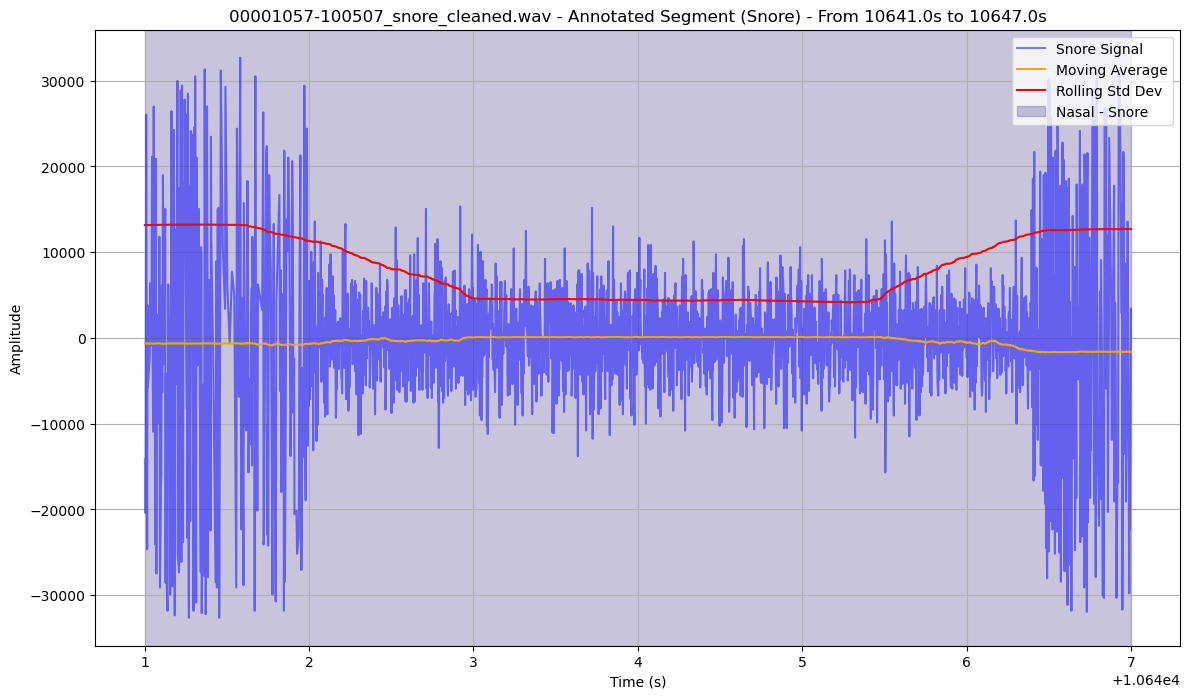

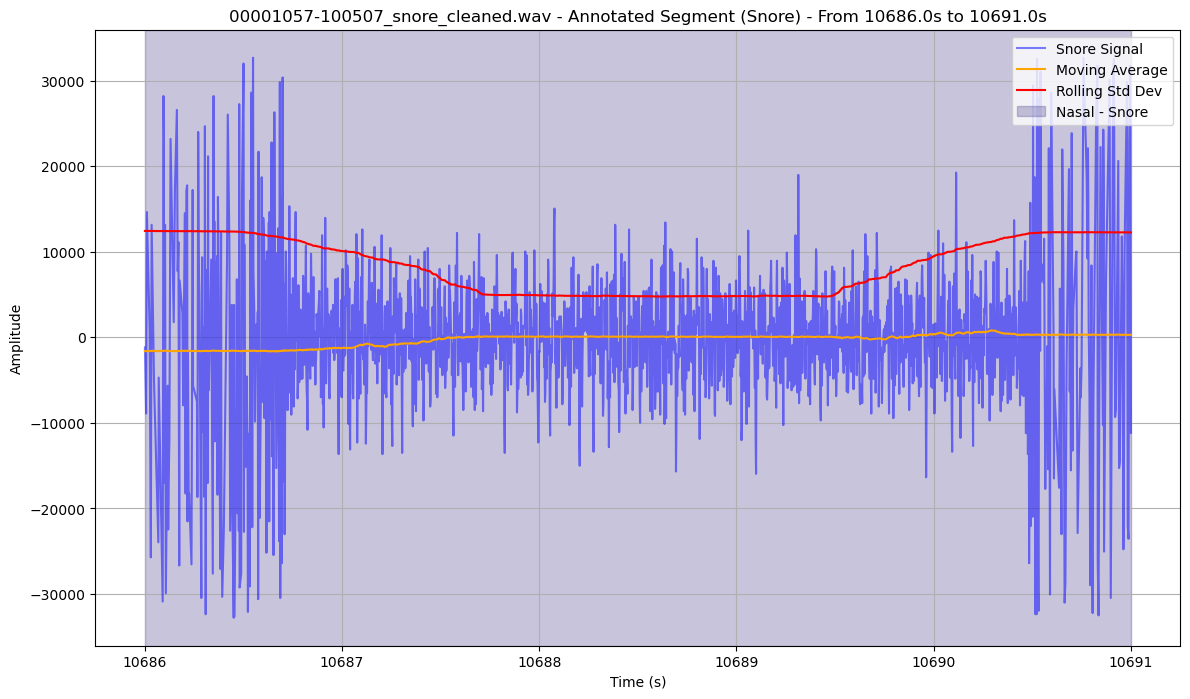

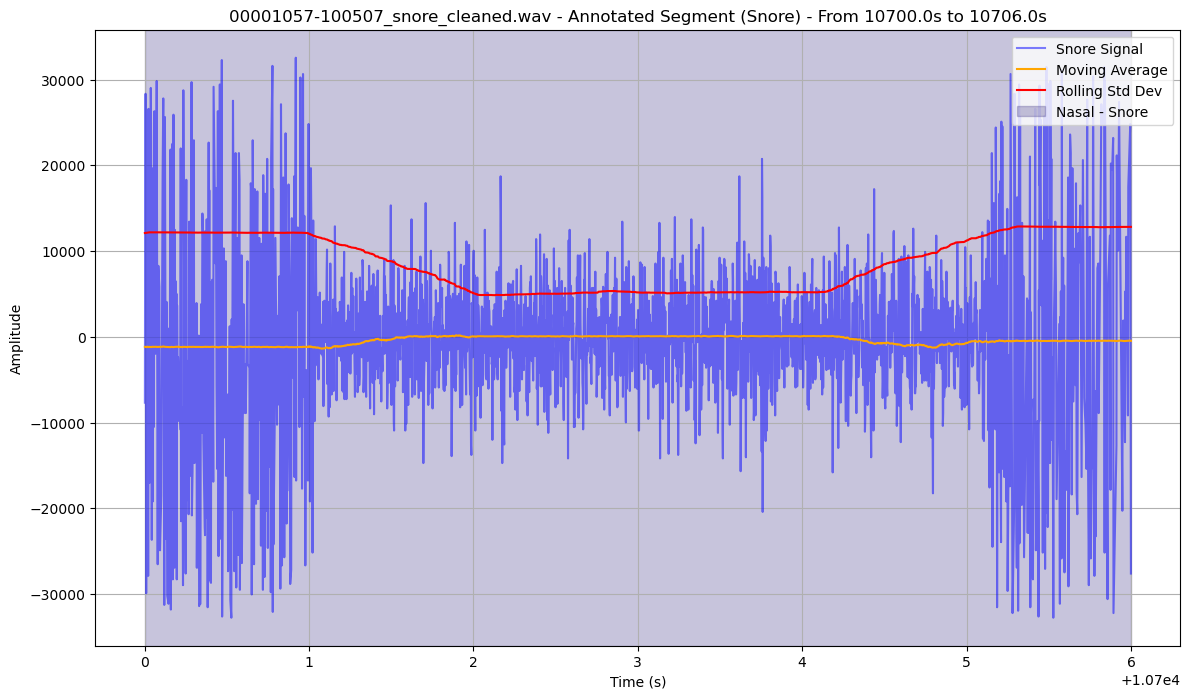

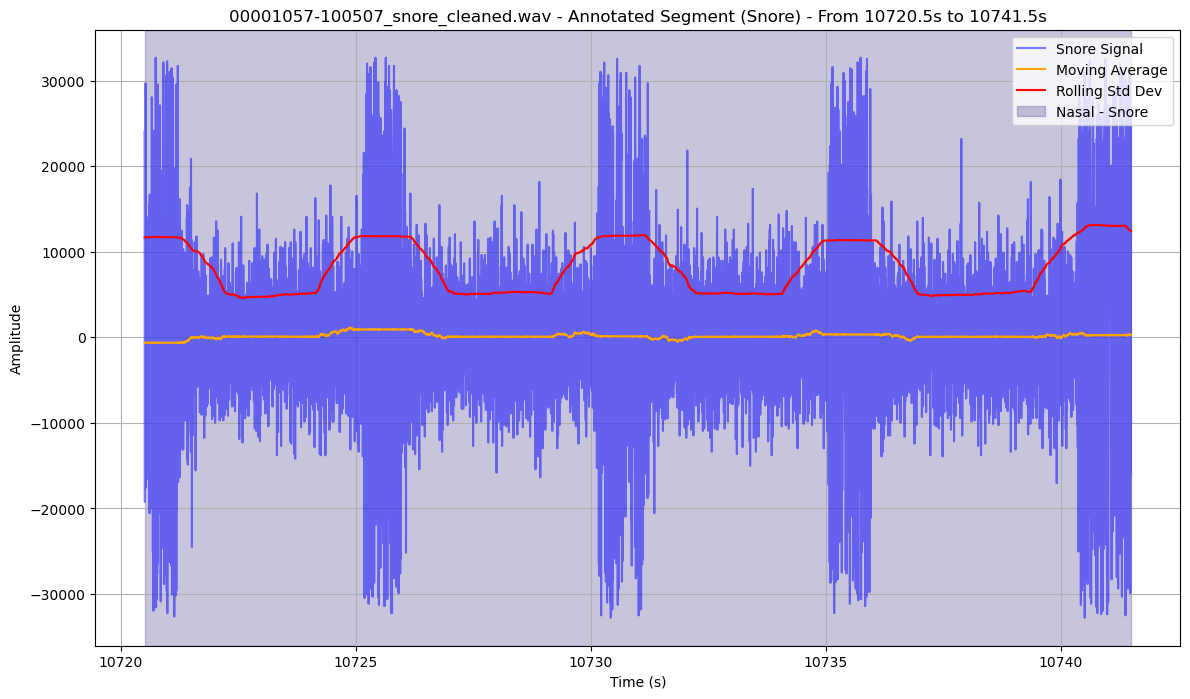

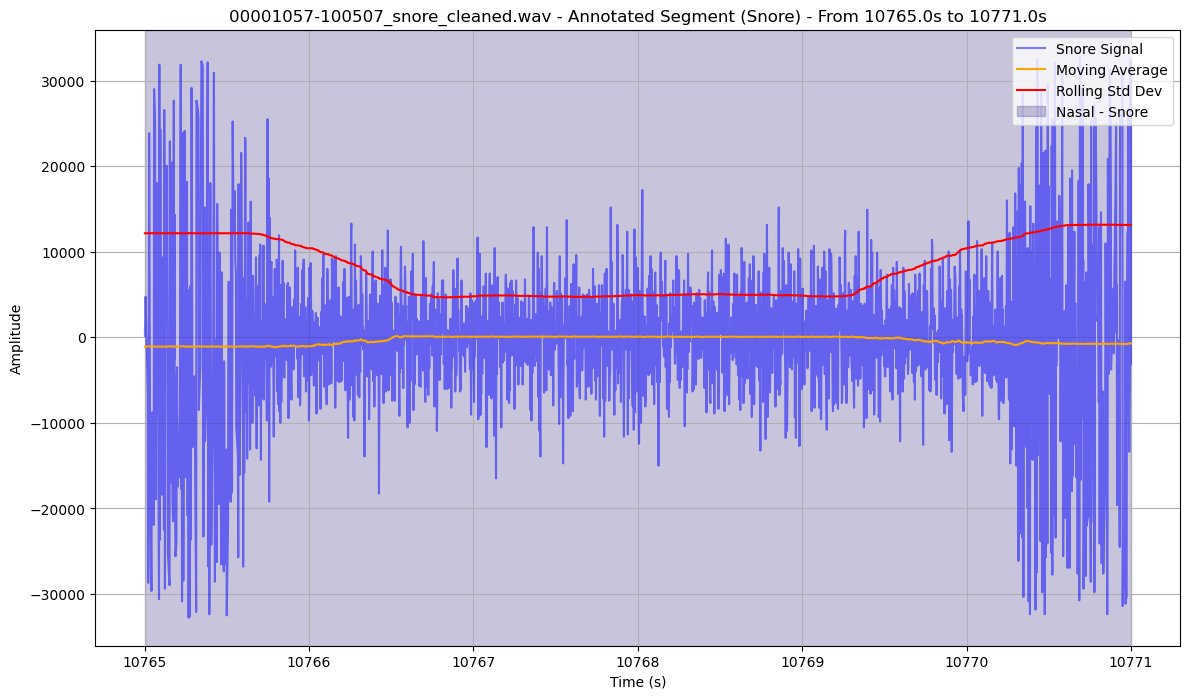

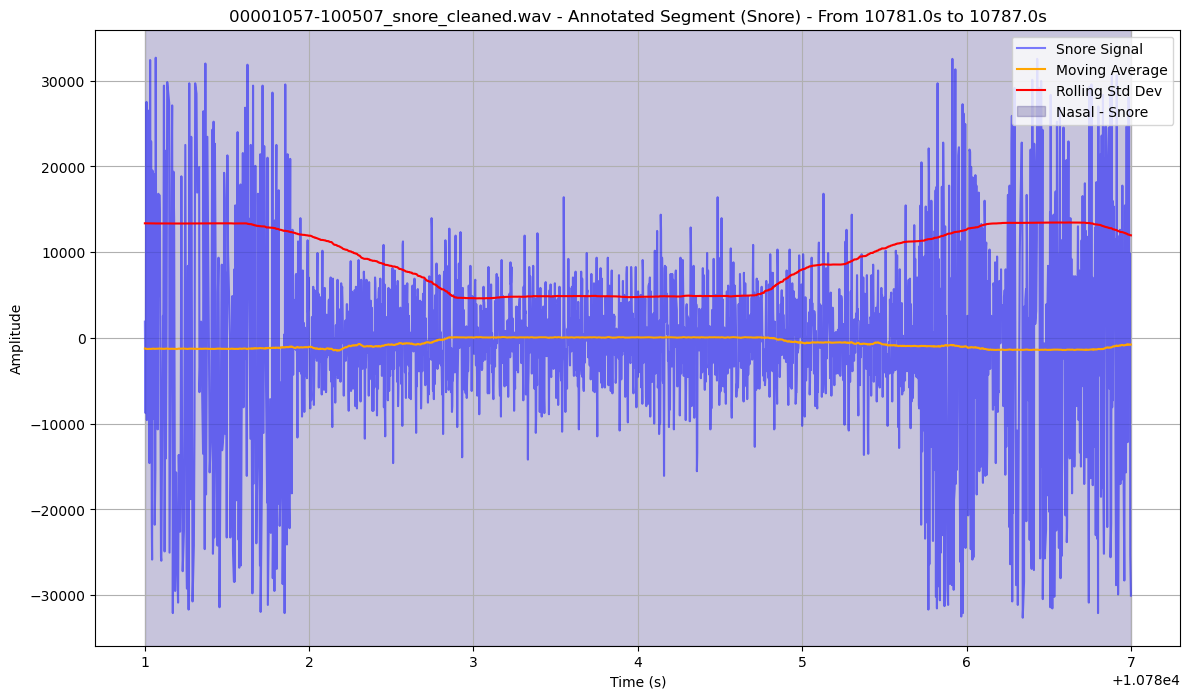

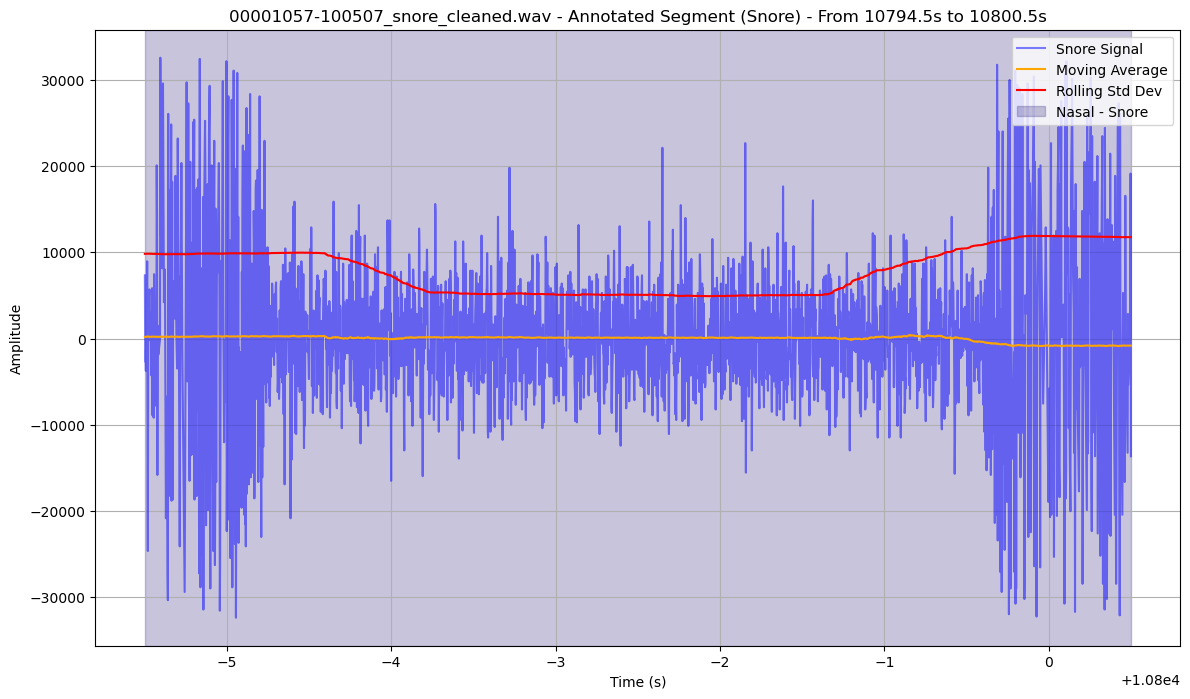

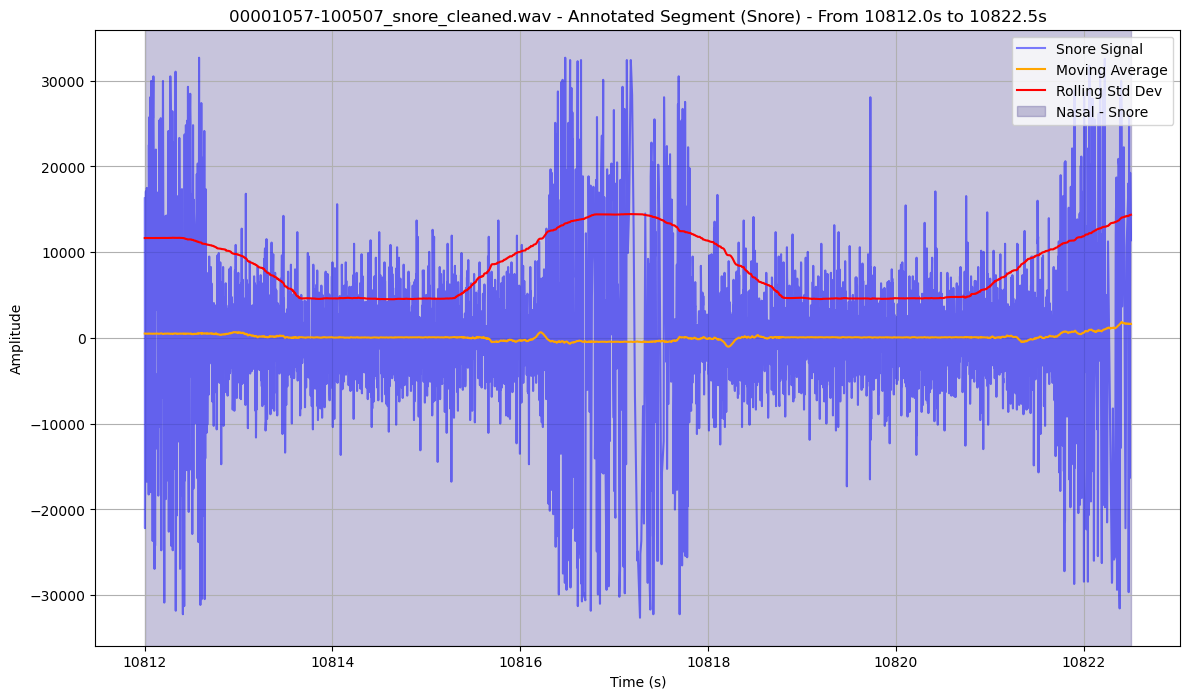

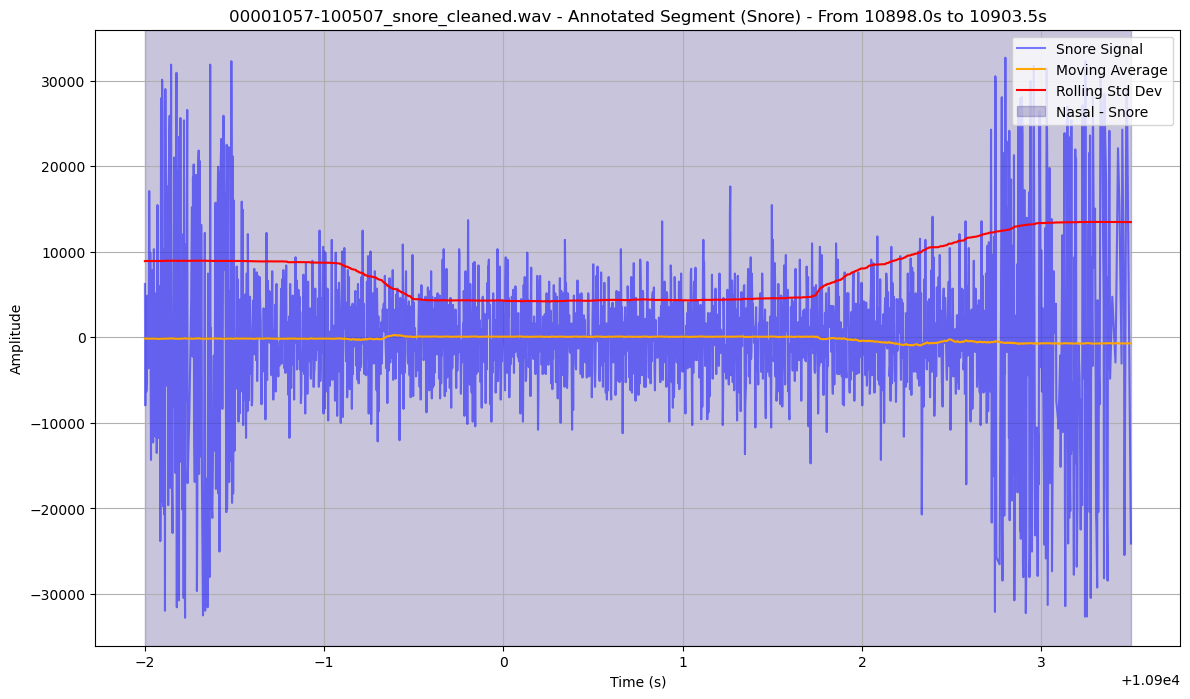

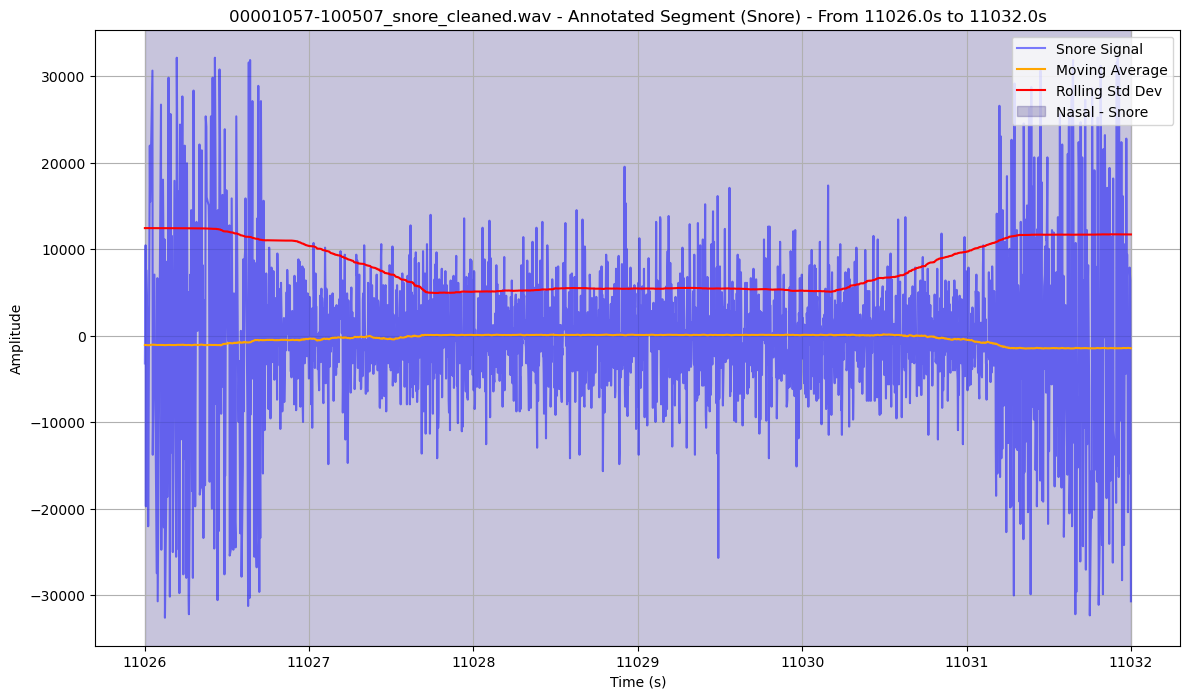

In [4]:
# Folder path for "1057" containing both .wav and .rml files
folder_path = '/Users/terlan/Library/CloudStorage/GoogleDrive-tarlan.sultanov01@gmail.com/.shortcut-targets-by-id/1FAWJCPKuxjfQ4HhAXFQk6-_8mbaATyK8/Team Project/Data Preprocessing/1057/'

# Initialize variables for file paths
wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
rml_files = [f for f in os.listdir(folder_path) if f.endswith('.rml')]

# Assuming there's only one .wav and one .rml file for the patient
if wav_files and rml_files:
    wav_file_path = os.path.join(folder_path, wav_files[0])
    rml_file_path = os.path.join(folder_path, rml_files[0])
    
    print(f"Using .wav file: {wav_file_path}")
    print(f"Using .rml file: {rml_file_path}")

    # Parse annotations from the .rml file, but only include "Nasal - Snore"
    def parse_rml_xml(rml_file_path):
        namespace = '{http://www.respironics.com/PatientStudy.xsd}'
        tree = ET.parse(rml_file_path)
        root = tree.getroot()
        annotations = []
        events_section = root.find(f"{namespace}ScoringData/{namespace}Events")
        if events_section is not None:
            for event in events_section.findall(f"{namespace}Event"):
                family = event.attrib.get("Family", "")
                event_type = event.attrib.get("Type", "")
                start_time = float(event.attrib.get("Start", "0"))
                duration = float(event.attrib.get("Duration", "0"))
                annotation_type = f"{family} - {event_type}"
                
                # Only include "Nasal - Snore"
                if annotation_type == "Nasal - Snore":
                    annotations.append({
                        'start': start_time,
                        'end': start_time + duration,
                        'type': annotation_type
                    })
        return annotations

    # Define color for "Nasal - Snore" annotation
    annotation_colors = {
        "Nasal - Snore": "darkslateblue"
    }

    # Function to plot only the annotated segments
    def plot_annotated_segments(wav_file_path, annotations, channel_name, window_size=1000):
        sampling_rate, data = wavfile.read(wav_file_path)
        time_axis = np.linspace(0, len(data) / sampling_rate, len(data))
        time_series = pd.Series(data, index=time_axis)
        moving_avg = time_series.rolling(window=window_size, center=True).mean()
        rolling_std = time_series.rolling(window=window_size, center=True).std()

        # Plot each annotation segment
        for annotation in annotations:
            start_time = annotation['start']
            end_time = annotation['end']
            segment_data = time_series[(time_series.index >= start_time) & (time_series.index <= end_time)]
            segment_moving_avg = moving_avg[(moving_avg.index >= start_time) & (moving_avg.index <= end_time)]
            segment_rolling_std = rolling_std[(rolling_std.index >= start_time) & (rolling_std.index <= end_time)]

            plt.figure(figsize=(14, 8))
            plt.plot(segment_data.index, segment_data, label=f"{channel_name} Signal", color='blue', alpha=0.5)
            plt.plot(segment_moving_avg.index, segment_moving_avg, label="Moving Average", color='orange')
            plt.plot(segment_rolling_std.index, segment_rolling_std, label="Rolling Std Dev", color='red')
            
            # Highlight the annotation
            plt.axvspan(start_time, end_time, color=annotation_colors["Nasal - Snore"], alpha=0.3, label=annotation['type'])

            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")
            plt.title(f"{os.path.basename(wav_file_path)} - Annotated Segment ({channel_name}) - From {start_time:.1f}s to {end_time:.1f}s")

            # Show only unique "Snore" in the legend
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            plt.legend(by_label.values(), by_label.keys(), loc="upper right")
            
            plt.grid(True)
            plt.show()

    # Parse and plot only "Nasal - Snore" annotated segments
    annotations = parse_rml_xml(rml_file_path)
    plot_annotated_segments(wav_file_path, annotations, channel_name="Snore", window_size=1000)

else:
    print("Error: Required .wav or .rml file not found in the specified folder.")

In [ ]:
# Folder path for "1057" containing both .wav and .rml files
folder_path = '/Users/terlan/Library/CloudStorage/GoogleDrive-tarlan.sultanov01@gmail.com/.shortcut-targets-by-id/1FAWJCPKuxjfQ4HhAXFQk6-_8mbaATyK8/Team Project/Data Preprocessing/1057/'

# Initialize variables for file paths
wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
rml_files = [f for f in os.listdir(folder_path) if f.endswith('.rml')]

# Check if there are .wav and .rml files available
if wav_files and rml_files:
    # Assuming there's only one .rml file for the patient in the folder
    rml_file_path = os.path.join(folder_path, rml_files[0])
    print(f"Using .rml file: {rml_file_path}")

    # Parse annotations from the .rml file, but only include "Nasal - Snore"
    def parse_rml_xml(rml_file_path):
        namespace = '{http://www.respironics.com/PatientStudy.xsd}'
        tree = ET.parse(rml_file_path)
        root = tree.getroot()
        annotations = []
        events_section = root.find(f"{namespace}ScoringData/{namespace}Events")
        if events_section is not None:
            for event in events_section.findall(f"{namespace}Event"):
                family = event.attrib.get("Family", "")
                event_type = event.attrib.get("Type", "")
                start_time = float(event.attrib.get("Start", "0"))
                duration = float(event.attrib.get("Duration", "0"))
                annotation_type = f"{family} - {event_type}"
                
                # Only include "Nasal - Snore"
                if annotation_type == "Nasal - Snore":
                    annotations.append({
                        'start': start_time,
                        'end': start_time + duration,
                        'type': annotation_type
                    })
        return annotations

    # Define color for "Nasal - Snore" annotation
    annotation_colors = {
        "Nasal - Snore": "darkslateblue"
    }

    # Function to plot only the annotated segments for each wav file
    def plot_annotated_segments(wav_file_path, annotations, channel_name, window_size=1000):
        sampling_rate, data = wavfile.read(wav_file_path)
        time_axis = np.linspace(0, len(data) / sampling_rate, len(data))
        time_series = pd.Series(data, index=time_axis)
        moving_avg = time_series.rolling(window=window_size, center=True).mean()
        rolling_std = time_series.rolling(window=window_size, center=True).std()

        # Plot each annotation segment
        for annotation in annotations:
            start_time = annotation['start']
            end_time = annotation['end']
            segment_data = time_series[(time_series.index >= start_time) & (time_series.index <= end_time)]
            segment_moving_avg = moving_avg[(moving_avg.index >= start_time) & (moving_avg.index <= end_time)]
            segment_rolling_std = rolling_std[(rolling_std.index >= start_time) & (rolling_std.index <= end_time)]

            plt.figure(figsize=(14, 8))
            plt.plot(segment_data.index, segment_data, label=f"{channel_name} Signal", color='blue', alpha=0.5)
            plt.plot(segment_moving_avg.index, segment_moving_avg, label="Moving Average", color='orange')
            plt.plot(segment_rolling_std.index, segment_rolling_std, label="Rolling Std Dev", color='red')
            
            # Highlight the annotation
            plt.axvspan(start_time, end_time, color=annotation_colors["Nasal - Snore"], alpha=0.3, label=annotation['type'])

            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")
            plt.title(f"{os.path.basename(wav_file_path)} - Annotated Segment ({channel_name}) - From {start_time:.1f}s to {end_time:.1f}s")

            # Show only unique "Snore" in the legend
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            plt.legend(by_label.values(), by_label.keys(), loc="upper right")
            
            plt.grid(True)
            plt.show()

    # Parse annotations
    annotations = parse_rml_xml(rml_file_path)

    # Loop through each .wav file and plot the annotated segments
    for wav_file in wav_files:
        wav_file_path = os.path.join(folder_path, wav_file)
        print(f"Processing .wav file: {wav_file_path}")
        plot_annotated_segments(wav_file_path, annotations, channel_name="Snore", window_size=1000)

else:
    print("Error: Required .wav or .rml file not found in the specified folder.")

In [ ]:
# Folder path for "1057" containing both .wav and .rml files
folder_path = '/Users/terlan/Library/CloudStorage/GoogleDrive-tarlan.sultanov01@gmail.com/.shortcut-targets-by-id/1FAWJCPKuxjfQ4HhAXFQk6-_8mbaATyK8/Team Project/Data Preprocessing/1057/'

# Initialize variables for file paths
wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
rml_files = [f for f in os.listdir(folder_path) if f.endswith('.rml')]

# Check if there are .wav and .rml files available
if wav_files and rml_files:
    # Assuming there's only one .rml file for the patient in the folder
    rml_file_path = os.path.join(folder_path, rml_files[0])
    print(f"Using .rml file: {rml_file_path}")

    # Define colors for apnea and snore annotations
    annotation_colors = {
        "Respiratory - ObstructiveApnea": "red",
        "Respiratory - CentralApnea": "purple",
        "Respiratory - MixedApnea": "orange",
        "Respiratory - Hypopnea": "green",
        "Nasal - Snore": "darkblue"
    }

    # Parse the .rml file to extract only apnea and nasal-snore annotations
    def parse_rml_xml(rml_file_path):
        namespace = '{http://www.respironics.com/PatientStudy.xsd}'
        tree = ET.parse(rml_file_path)
        root = tree.getroot()
        annotations = []
        events_section = root.find(f"{namespace}ScoringData/{namespace}Events")
        if events_section is not None:
            for event in events_section.findall(f"{namespace}Event"):
                family = event.attrib.get("Family", "")
                event_type = event.attrib.get("Type", "")
                start_time = float(event.attrib.get("Start", "0"))
                duration = float(event.attrib.get("Duration", "0"))
                annotation_type = f"{family} - {event_type}"
                
                # Include only apnea and nasal-snore annotations
                if annotation_type in annotation_colors:
                    annotations.append({
                        'start': start_time,
                        'end': start_time + duration,
                        'type': annotation_type
                    })
        return annotations

    # Function to plot only the annotated segments for each wav file
    def plot_annotated_segments(wav_file_path, annotations, channel_name, window_size=1000):
        sampling_rate, data = wavfile.read(wav_file_path)
        time_axis = np.linspace(0, len(data) / sampling_rate, len(data))
        time_series = pd.Series(data, index=time_axis)
        moving_avg = time_series.rolling(window=window_size, center=True).mean()
        rolling_std = time_series.rolling(window=window_size, center=True).std()

        # Plot each annotation segment with distinct colors
        for annotation in annotations:
            start_time = annotation['start']
            end_time = annotation['end']
            segment_data = time_series[(time_series.index >= start_time) & (time_series.index <= end_time)]
            segment_moving_avg = moving_avg[(moving_avg.index >= start_time) & (moving_avg.index <= end_time)]
            segment_rolling_std = rolling_std[(rolling_std.index >= start_time) & (rolling_std.index <= end_time)]

            plt.figure(figsize=(14, 8))
            plt.plot(segment_data.index, segment_data, label=f"{channel_name} Signal", color='blue', alpha=0.5)
            plt.plot(segment_moving_avg.index, segment_moving_avg, label="Moving Average", color='orange')
            plt.plot(segment_rolling_std.index, segment_rolling_std, label="Rolling Std Dev", color='red')
            
            # Highlight the annotation with the appropriate color
            annotation_color = annotation_colors[annotation['type']]
            plt.axvspan(start_time, end_time, color=annotation_color, alpha=0.3, label=annotation['type'])

            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")
            plt.title(f"{os.path.basename(wav_file_path)} - Annotated Segment ({channel_name}) - From {start_time:.1f}s to {end_time:.1f}s")

            # Show only unique annotation types in the legend
            handles, labels = plt.gca().get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            plt.legend(by_label.values(), by_label.keys(), loc="upper right")
            
            plt.grid(True)
            plt.show()

    # Parse annotations
    annotations = parse_rml_xml(rml_file_path)

    # Loop through each .wav file and plot the annotated segments
    for wav_file in wav_files:
        wav_file_path = os.path.join(folder_path, wav_file)
        print(f"Processing .wav file: {wav_file_path}")
        plot_annotated_segments(wav_file_path, annotations, channel_name="Snore", window_size=1000)

else:
    print("Error: Required .wav or .rml file not found in the specified folder.")

In [ ]:
#reduced the number of data points
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import xml.etree.ElementTree as ET
import pandas as pd

# List of folders to process
folders = [
    '/Users/terlan/Library/CloudStorage/GoogleDrive-tarlan.sultanov01@gmail.com/.shortcut-targets-by-id/1FAWJCPKuxjfQ4HhAXFQk6-_8mbaATyK8/Team Project/Data Preprocessing/1010/',
    '/Users/terlan/Library/CloudStorage/GoogleDrive-tarlan.sultanov01@gmail.com/.shortcut-targets-by-id/1FAWJCPKuxjfQ4HhAXFQk6-_8mbaATyK8/Team Project/Data Preprocessing/1057/'
]

# Define colors for apnea and nasal-snore annotations
annotation_colors = {
    "Respiratory - ObstructiveApnea": "red",
    "Respiratory - CentralApnea": "purple",
    "Respiratory - MixedApnea": "orange",
    "Respiratory - Hypopnea": "green",
    "Nasal - Snore": "darkblue"
}

# Down-sampling factor (adjust this value to control the number of points in the plot)
downsample_factor = 100

# Parse the .rml file to extract only apnea and nasal-snore annotations
def parse_rml_xml(rml_file_path):
    namespace = '{http://www.respironics.com/PatientStudy.xsd}'
    tree = ET.parse(rml_file_path)
    root = tree.getroot()
    annotations = []
    events_section = root.find(f"{namespace}ScoringData/{namespace}Events")
    if events_section is not None:
        for event in events_section.findall(f"{namespace}Event"):
            family = event.attrib.get("Family", "")
            event_type = event.attrib.get("Type", "")
            start_time = float(event.attrib.get("Start", "0"))
            duration = float(event.attrib.get("Duration", "0"))
            annotation_type = f"{family} - {event_type}"
            
            # Include only apnea and nasal-snore annotations
            if annotation_type in annotation_colors:
                annotations.append({
                    'start': start_time,
                    'end': start_time + duration,
                    'type': annotation_type
                })
    return annotations

# Function to plot the full graph with annotations for each wav file with down-sampling
def plot_full_graph_with_annotations(wav_file_path, annotations, channel_name):
    sampling_rate, data = wavfile.read(wav_file_path)
    
    # Down-sample the data by averaging over every `downsample_factor` points
    data_downsampled = data[:len(data) // downsample_factor * downsample_factor].reshape(-1, downsample_factor).mean(axis=1)
    time_axis = np.linspace(0, len(data) / sampling_rate, len(data_downsampled))

    plt.figure(figsize=(16, 8))
    plt.plot(time_axis, data_downsampled, label=f"{channel_name} Signal", color='blue', alpha=0.5)

    # Highlight each annotation on the full graph
    for annotation in annotations:
        annotation_color = annotation_colors[annotation['type']]
        plt.axvspan(annotation['start'], annotation['end'], color=annotation_color, alpha=0.3, label=annotation['type'])

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"{os.path.basename(wav_file_path)} - Full Time-Series Plot with Annotations ({channel_name})")

    # Show only unique annotation types in the legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc="upper right")
    
    plt.grid(True)
    plt.show()

# Iterate through each folder and process the files
for folder_path in folders:
    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    rml_files = [f for f in os.listdir(folder_path) if f.endswith('.rml')]

    # Check if there are .wav and .rml files available in the folder
    if wav_files and rml_files:
        # Assuming there's only one .rml file for the patient in the folder
        rml_file_path = os.path.join(folder_path, rml_files[0])
        print(f"Using .rml file: {rml_file_path}")

        # Parse annotations from the .rml file
        annotations = parse_rml_xml(rml_file_path)

        # Loop through each .wav file and plot the full time-series with annotations
        for wav_file in wav_files:
            wav_file_path = os.path.join(folder_path, wav_file)
            print(f"Processing .wav file: {wav_file_path}")
            plot_full_graph_with_annotations(wav_file_path, annotations, channel_name="Snore")

    else:
        print(f"Error: Required .wav or .rml file not found in the folder {folder_path}.")